# Comparación de métodos de Clustering: K-Means vs DBSCAN

El **objetivo** de esta práctica es **observar** la **diferencia** entre los métodos de agrupación **K-Means** y **DBSCAN** y **comparar su rendimiento** en situaciones concretas. Trabajaremos con datos simulados representando formas de grupos anidadas para ver el desempeño de ambos algoritmos con estos datos.

Es fundamental destacar que K-Means es un algortimo de agrupación particional basado en la distancia a los  centroides, mientras que DBSCAN es de agrupación por densidad, es decir, clusteriza datos en regiones localmente densas.

## Importación de librerías

In [2]:
# 📌 Manipulación de datos
import numpy as np  # Operaciones numéricas y manejo de arrays
import pandas as pd  # Manejo de DataFrames

# 📌 Algoritmos de Clustering
from sklearn.cluster import DBSCAN  # Clustering basado en densidad
from sklearn.cluster import KMeans  # Clustering basado en centroides

# 📌 Evaluación del Clustering
from sklearn.metrics import silhouette_score  # Cálculo del coeficiente de silueta

# 📌 Vecindades y distancias
from sklearn.neighbors import NearestNeighbors  # Cálculo de vecinos más cercanos

# 📌 Visualización de datos
import matplotlib.pyplot as plt  # Gráficos básicos
import seaborn as sns  # Visualización avanzada con Seaborn
from matplotlib.colors import ListedColormap  # Manejo de colores en gráficos
from mpl_toolkits.mplot3d import Axes3D  # Visualización 3D

## Generación aleatoria de los datos

Generamos datos aleatorios, tres círculos de diferente radio (con bordes con ruido) a diferentes alturas. Vamos a visualizarlos en dos y tres dimensiones utilizando matplotlib.

<Axes: title={'center': 'Top-Down View'}, xlabel='X', ylabel='Y'>

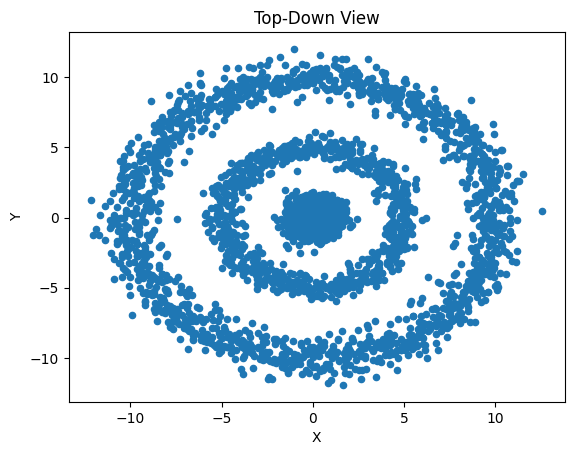

In [3]:
import numpy as np

def Rads(degree):
    return degree * (np.pi / 180)  # Convierte grados a radianes

points = []  # Lista donde se almacenarán los puntos generados

for z in [0, 10]:  # Se generan puntos en dos niveles de altura Z = 0 y Z = 10
    for r in [1, 5, 10, 10]:  # Radios de los círculos
        for d in range(360):  # Itera sobre los ángulos de 0° a 359° (un punto por cada grado)

            if r < 10:
                radius = np.random.normal(loc=r, scale=0.5)  # Si r < 10, el radio tiene una variación pequeña (desviación 0.5)
            else:
                radius = np.random.normal(loc=r, scale=0.75)  # Si r = 10, el radio tiene una mayor variación (desviación 0.75)

            points.append([
                radius * np.cos(Rads(d)),  # Coordenada X usando coseno
                radius * np.sin(Rads(d)),  # Coordenada Y usando seno
                np.random.normal(loc=z, scale=0.75)  # Coordenada Z con ruido (desviación 0.75)
            ])


RandomData = pd.DataFrame(points,columns = ['X','Y','Z'])
RandomData.plot(kind = 'scatter', x = 'X', y = 'Y', title = 'Top-Down View')

<ipython-input-4-8bf96599aa57>:9: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


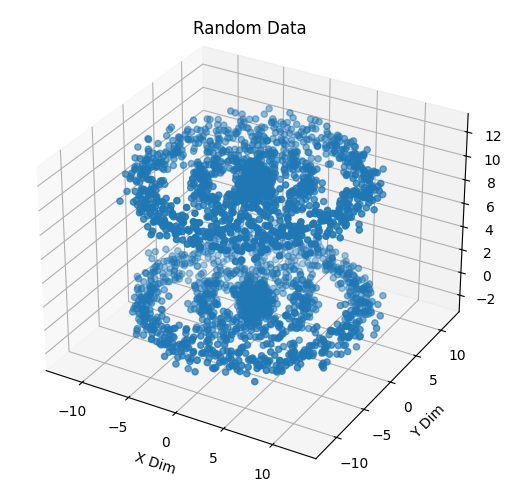

In [4]:
fig = plt.figure()
ax = Axes3D(fig, auto_add_to_figure = False)
fig.add_axes(ax)
sc = ax.scatter(RandomData['X'],RandomData['Y'],RandomData['Z'])
ax.set_xlabel('X Dim')
ax.set_ylabel('Y Dim')
ax.set_zlabel('Z Dim')
fig.suptitle('Random Data')
plt.tight_layout()
plt.show()

Podemos observar la estructura de los datos,  se ve que en cada “capa” (por un valor fijo de Z) existen tres círculos concéntricos (o anidados) de distinto radio, distribuidos uniformemente en el plano XY. Luego, esa misma estructura de tres círculos se repite a otra altura (otro valor de Z), de modo que en total hay dos “capas” con la misma configuración circular, pero a diferentes profundidades en el eje Z.

## K-Means Clustering

Ahora vamos a realizar el agrupamiento de estos puntos con el algoritmo de K-Means. Observando las estructura ya sabemos que existen 6 clústers diferenciados, pero vamos a aplicar el método del codo y la silueta para ver qué valor de K óptimo nos indican.

In [5]:
sum_of_sqr_dist = {}

#Ponemos 1000 como máximo de iteraciones (de default son 300) e inicialización optimizada

for k in range(1, 10):
    km = KMeans(n_clusters=k, init='k-means++', max_iter=1000)
    km = km.fit(RandomData)
    sum_of_sqr_dist[k] = km.inertia_

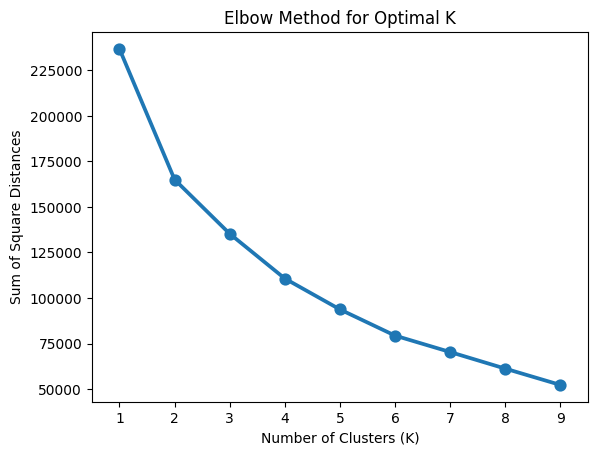

In [6]:
sns.pointplot(x=list(sum_of_sqr_dist.keys()), y=list(sum_of_sqr_dist.values()))
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Sum of Square Distances")
plt.title("Elbow Method for Optimal K")
plt.show()

In [7]:
silhouette = {}

for k in range(2,8):
    km = KMeans(n_clusters=k, init='k-means++', max_iter=1000)
    km.fit(RandomData)
    silhouette[k] = silhouette_score(RandomData, km.labels_)

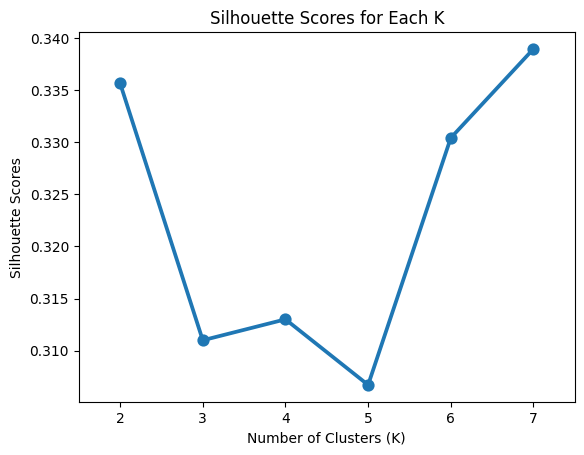

In [8]:
sns.pointplot(x=list(silhouette.keys()), y=list(silhouette.values()))
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Scores")
plt.title("Silhouette Scores for Each K")
plt.show()

Con el método del codo no se visualiza una K claramente, y la silueta nos indica un valor de K=7 ccomo el óptimo. Nosotros hemos hecho "trampa" al visualizar los datos porque ya conocemos su estructura pero es un buen ejemplo de cómo los métodos de aproximación de parámetros en clustering sirven como guía, pero no son verdades inamovibles. Por ello, se requiere siempre un análisis completo y visualizar gráficamente los datos si es posible.

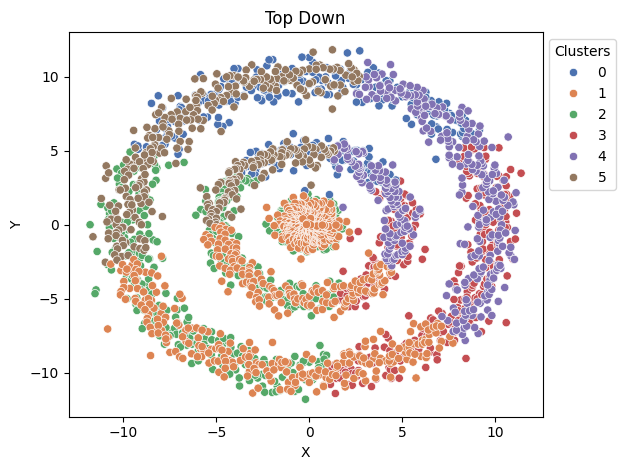

In [10]:
km = KMeans(n_clusters = 6, init='k-means++', max_iter=1000)
km.fit(RandomData)
Grouping_Labels = km.labels_
p = sns.scatterplot (data = RandomData, x = 'X',  y= 'Y', hue = Grouping_Labels, legend = 'full', palette = "deep")
sns.move_legend(p, "upper right", bbox_to_anchor = (1.17, 1.), title = 'Clusters')
plt.title('Top Down')
plt.tight_layout()
plt.show()

<ipython-input-11-7526ef62f67d>:11: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


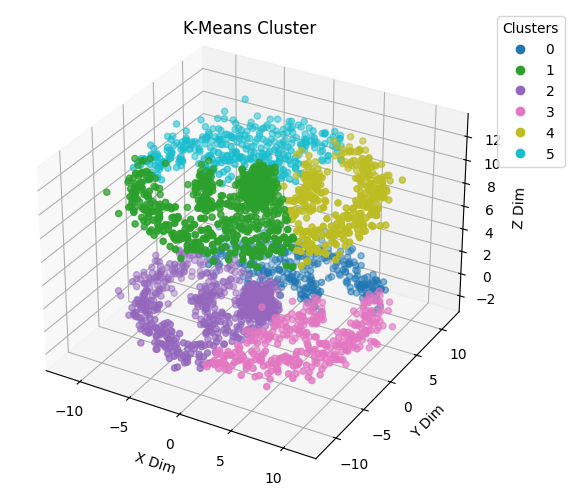

In [11]:
fig = plt.figure()
ax = Axes3D(fig, auto_add_to_figure = False)
fig.add_axes(ax)
cmap = ListedColormap(sns.color_palette("tab10").as_hex())
sc = ax.scatter(RandomData['X'],RandomData['Y'],RandomData['Z'], c = Grouping_Labels, cmap = cmap)
ax.set_xlabel('X Dim')
ax.set_ylabel('Y Dim')
ax.set_zlabel('Z Dim')
plt.legend(*sc.legend_elements(),bbox_to_anchor = (1.17, 1.), title = 'Clusters')
fig.suptitle('K-Means Cluster')
plt.tight_layout()
plt.show()

Aquí vemos el principal problema de usar K-means en esta aplicación. Dado que el objetivo es minimizar la suma de los cuadrados dentro de los clústeres (within sum of squares), puntos de múltiples anillos terminan en el mismo clúster.Cómo ya vimos en teoría, genera clústeres esféricos y en este caso con estructuras anidadas no es capaz de reconocerlas de la manera correcta.

## DBSCAN

Ahora vamos a implementar DBSCAN, algoritmo de agrupación por densidad, para ver cómo es capaz de agrupar nuestros datos y comparar los resultados con los obtenidos por K-Means.

No osbtante, primero hay que elegir un buen valor para los parámetros:


*   ***Epsilon*** (radio de vecindad). Utilizaremos el método de la k-ésima distancia.
*   ***MinPts***. Seguiremos la regla general de elegir un valor igual a 2 veces la dimensionalidad. En nuestro caso, MinPts = 6, ya que tenemos las 3 dimensiones como características.



**Método de la k-ésima distancia**: El gráfico siguiente se utiliza para ayudar a identificar el valor correcto de EPS a emplear. Utilizaremos los siguientes criterios:


1. Definir el valor de K. Generalmente K = MinPoints.

2. Calcular la distancia al k-ésimo vecino más cercano para cada punto.

3. Ordenar todas las distancias de los puntos de mayor a menor.

4. Gráficar las distancias k-ésimas (eje y) frente a los índices de los puntos ordenados (eje x).

5. Seleccionar eps como el valor o rango de valores para los cuáles hay un codo o cambio significativo en la curvatura

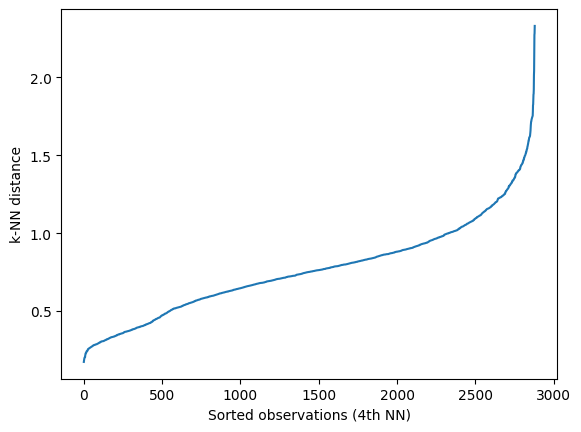

In [24]:
nbrs = NearestNeighbors(n_neighbors = 5).fit(RandomData)
neigh_dist, neigh_ind = nbrs.kneighbors(RandomData)
sort_neigh_dist = np.sort(neigh_dist, axis = 0)

k_dist = sort_neigh_dist[:, 4] #looking for the min_points - 1 NN ordered.
plt.plot(k_dist)
plt.ylabel("k-NN distance")
plt.xlabel("Sorted observations (4th NN)")
plt.show()

Podemos asumir que un buen valor para Epsilon estará entorno a 1.2 observando la gráfica.

In [21]:
clusters = DBSCAN(eps = 1.2, min_samples = 6).fit(RandomData) #eps is knee of above plot, min_samples is typically 2 * dimensions
# get cluster labels
print(clusters.labels_) #labesl
print(clusters.n_features_in_) #features used in calculation
print(clusters.feature_names_in_) #names of features in fit
set(clusters.labels_)

[0 0 0 ... 5 5 5]
3
['X' 'Y' 'Z']


{-1, 0, 1, 2, 3, 4, 5}

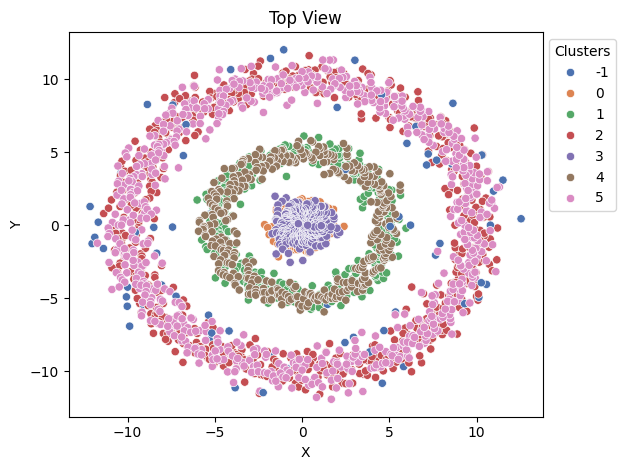

In [22]:
p = sns.scatterplot(data = RandomData, x = 'X',  y= 'Y', hue = clusters.labels_, legend = 'full', palette = "deep")
sns.move_legend(p, "upper right", bbox_to_anchor = (1.17, 1.), title = 'Clusters')
plt.title('Top View')
plt.tight_layout()
plt.show()

<ipython-input-23-cd1b39a6b676>:11: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


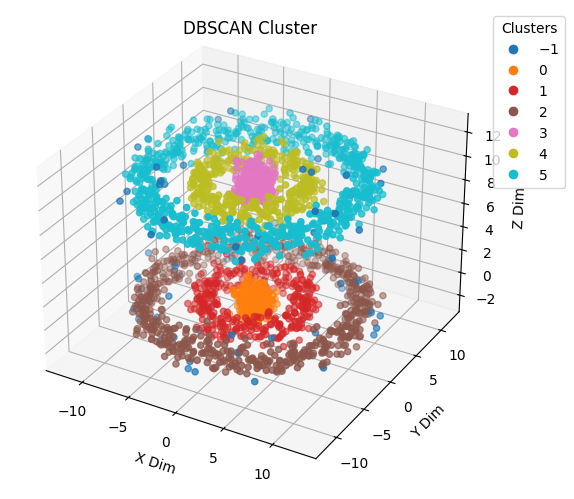

In [23]:
fig = plt.figure()
ax = Axes3D(fig, auto_add_to_figure = False)
fig.add_axes(ax)
cmap = ListedColormap(sns.color_palette("tab10").as_hex())
sc = ax.scatter(RandomData['X'],RandomData['Y'],RandomData['Z'], c = clusters.labels_, cmap = cmap)
ax.set_xlabel('X Dim')
ax.set_ylabel('Y Dim')
ax.set_zlabel('Z Dim')
plt.legend(*sc.legend_elements(),bbox_to_anchor = (1.17, 1.), title = 'Clusters')
fig.suptitle('DBSCAN Cluster')
plt.tight_layout()
plt.show()

Los gráficos anteriores muestran un resultado por pate de DBSCCAN mucho más claro al agrupar los puntos de datos en clústeres distintos. Este algoritmo, al funcionar por densidad, sí que reconoce la estructura de nuestros datos Hay algunos puntos de "ruido" alrededor de los bordes de los anillos, lo cual es esperable.

**Contenido adicional**: Podemos jugar con los valores de los parámetros y ejecutar DBSCAN para visualizar cómo cambian las agrupaciones y cómo de sensible es el método a determinadas variaciones de los parámetros.